In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from collections import Counter

from functions import *

In [2]:
# Load ground truth
df_gt = pd.read_csv('./A3_primary_school_network/metadata_primary_school.txt', sep=' ')
# Create a dictionary for easy lookup: {node_id: "class_label"}
ground_truth_dict = dict(zip(df_gt['node'], df_gt['school_group']))

In [3]:
def set_color_nodes(communities, G):
    color_nodes = []
    node_colors_dict = {}
    
    for community in communities:
        # Получаем реальные метки для узлов в этом найденном комьюнити
        gt_labels_in_comm = [
            ground_truth_dict.get(str(node)) 
            for node in community 
            if str(node) in ground_truth_dict
        ]
        
        if gt_labels_in_comm:
            # Находим самый часто встречающийся реальный класс в этом комьюнити
            most_common_gt = Counter(gt_labels_in_comm).most_common(1)[0][0]
            assigned_color = group_to_color[most_common_gt]
        else:
            # Резервный цвет, если у узлов нет ground truth
            assigned_color = (0.7, 0.7, 0.7, 1.0) # Серый
        
        # Назначаем этот цвет всем узлам текущего найденного комьюнити
        for node in community:
            node_colors_dict[node] = assigned_color
            
    # Формируем итоговый список цветов в правильном порядке узлов графа
    for node in G.nodes():  
        color_nodes.append(node_colors_dict.get(node, (0.7, 0.7, 0.7, 1.0)))
        
    return color_nodes

In [4]:
def get_predicted_labels(communities, nodes):
    # Map each node to its community index
    node_to_comm = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_comm[node] = i
    
    # Return labels in the specific node order
    return [node_to_comm[node] for node in nodes]

In [5]:
def save_as_pajek_clu(communities, nodes, filename="communities.clu"):
    # 1. Map each node to its community index
    node_to_comm = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_comm[node] = i
            
    # 2. Write to file
    with open(filename, 'w') as f:
        # Pajek header
        f.write(f"*Vertices {len(nodes)}\n")
        
        # Write the community ID for each node in order
        for node in nodes:
            # We use +1 if you want Pajek to start counting from 1 instead of 0
            f.write(f"{node_to_comm[node]}\n")
            
    print(f"File saved successfully as: {filename}")

In [6]:
def run_community_algorithm(algorithm, G, w_key, resolution):
    """Шаг 1: Запуск выбранного алгоритма кластеризации."""
    if algorithm == 'louvain':
        return nx.community.louvain_communities(G, weight=w_key, seed=123, resolution=resolution)
    elif algorithm == 'infomap':
        return infomap_to_networkx_communities(G)
    elif algorithm == 'greedy':
        return nx.community.greedy_modularity_communities(G, weight=w_key, resolution=resolution)
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

In [7]:
def calculate_metrics(G, nodes, communities, w_key):
    y_true_labels = [ground_truth_dict[str(node)] for node in nodes]
    y_pred = get_predicted_labels(communities, nodes)
    
    le = LabelEncoder()
    y_true_for_metrics = le.fit_transform(y_true_labels)
    
    metrics = {
        'modularity': nx.community.modularity(G, communities, weight=w_key),
        'nmi': normalized_mutual_info_score(y_true_for_metrics, y_pred, average_method='arithmetic'),
        'jaccard': community_jaccard(y_true_for_metrics, y_pred),
        'nvi': normalized_vi(y_true_for_metrics, y_pred)
    }
    return y_true_labels, y_pred, metrics

In [8]:
def get_edge_styles(G, weighted):
    if weighted:
        weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
        max_weight = max(weights) if weights else 1
        edge_widths = [(w / max_weight) * 3.0 + 0.5 for w in weights]
        edge_alpha = 0.4
    else:
        edge_widths = 1.0
        edge_alpha = 0.3
        max_weight = 1.0
    return edge_widths, edge_alpha, max_weight

In [9]:
def plot_bar_chart(y_true_labels, y_pred, title_suffix, filename_base):
    plt.figure(figsize=(8, 6))
    true_dict = Counter(y_true_labels)
    pred_dict = Counter(y_pred)
    
    labels = sorted(true_dict.keys())
    true_vals = [true_dict[label] for label in labels]
    pred_vals_sorted = sorted(pred_dict.values(), reverse=True)
    pred_vals_padded = pred_vals_sorted + [0] * (len(labels) - len(pred_vals_sorted))
    pred_vals_final = pred_vals_padded[:len(labels)]

    x = np.arange(len(labels))
    width = 0.35
    rects1 = plt.bar(x - width/2, true_vals, width, label='Ground Truth', color='skyblue')
    rects2 = plt.bar(x + width/2, pred_vals_final, width, label='Predicted', color='salmon')
    
    plt.ylabel('Number of Students/Nodes')
    plt.title(f"Community Comparison: {title_suffix}", fontsize=14)
    plt.xticks(x, labels, rotation=45) 
    plt.legend()
    plt.bar_label(rects1, padding=3)
    plt.bar_label(rects2, padding=3)
    plt.tight_layout()
    plt.savefig(f"{filename_base} bar.png", dpi=300)
    plt.show()

In [10]:
def plot_fruchterman_reingold(G, pos, colors, metrics, num_communities, title_suffix, edge_widths, edge_alpha, filename_base):
    plt.figure(figsize=(7, 7))
    
    # Используем ПЕРЕДАННЫЕ координаты (pos), а не считаем их заново
    nx.draw_networkx_nodes(G, pos, node_size=60, node_color=colors, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, edge_color='grey', width=edge_widths)
    
    title_fr = (
        f"Fruchterman-Reingold Layout ({title_suffix})\n"
        f"{num_communities} communities | Modularity: {metrics['modularity']:.3f}\n"
        f"NMI: {metrics['nmi']:.3f} | Jaccard: {metrics['jaccard']:.3f} | NVI: {metrics['nvi']:.3f}"
    )
    plt.title(title_fr, fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{filename_base} fr layout.png", dpi=300)
    plt.show()

In [11]:
def detect_communities(algorithm, G, resolution=1.0, weighted=False, pos_fr=None):
    w_key = 'weight' if weighted else None
    nodes = list(G.nodes())
    title_suffix = f"{algorithm.upper()} ({'Weighted' if weighted else 'Unweighted'})"
    
    communities = run_community_algorithm(algorithm, G, w_key, resolution)
    num_communities = len(communities)
    filename_base = f"{algorithm} results {resolution} {num_communities} {'weighted' if weighted else 'unweighted'}"
    
    y_true_labels, y_pred, metrics = calculate_metrics(G, nodes, communities, w_key)
    colors = set_color_nodes(communities, G)
    edge_widths, edge_alpha, max_weight = get_edge_styles(G, weighted)

    # Визуализация
    plot_bar_chart(y_true_labels, y_pred, title_suffix, filename_base)
    
    plot_fruchterman_reingold(
        G, pos_fr, colors, metrics, num_communities, title_suffix, 
        edge_widths, edge_alpha, filename_base
    )

In [12]:
file_path = "A3_primary_school_network/primaryschool_u.net"
G_multi = nx.read_pajek(file_path)
G_unweighted = nx.Graph(G_multi)

In [13]:
G_multi = nx.read_pajek("A3_primary_school_network/primaryschool_w.net")

G_weighted = nx.Graph(G_multi)
edge_data = list(G_weighted.edges(data=True))[0]
print(f"Example edge data: {edge_data}")

Example edge data: ('1', '2', {'weight': 18.0})


In [14]:
for u, v, d in G_weighted.edges(data=True):
    # If the file used 'value' instead of 'weight'
    if 'value' in d and 'weight' not in d:
        d['weight'] = d['value']

for u, v, d in G_weighted.edges(data=True):
    d['weight'] = float(d['weight'])

In [15]:
master_pos = nx.fruchterman_reingold_layout(G_weighted, k=0.5, seed=42, weight='weight')

In [16]:
def plot_ground_truth(G, pos, ground_truth_dict, edge_widths, edge_alpha, filename_base):
    plt.figure(figsize=(7, 7)) 
    
    nx.draw_networkx_edges(G, pos, alpha=edge_alpha, edge_color='grey', width=edge_widths)
    
    unique_groups = sorted(list(set(ground_truth_dict.values())))
    
    for group in unique_groups:
        nodes_in_group = [n for n in G.nodes() if ground_truth_dict.get(str(n)) == group]
        
        if nodes_in_group:
            nx.draw_networkx_nodes(
                G, pos, 
                nodelist=nodes_in_group,
                node_size=60, 
                node_color=[group_to_color[group]], # <--- ИСПОЛЬЗУЕМ ГЛОБАЛЬНЫЙ СЛОВАРЬ
                edgecolors='black', 
                linewidths=0.5,
                label=group 
            )
    
    plt.title(f"Ground Truth Layout", fontsize=14)
    plt.legend(scatterpoints=1, title="School Groups", loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"{filename_base}_ground_truth.png", dpi=300, bbox_inches='tight')
    plt.show()

In [25]:
# Получаем уникальные группы и создаем палитру rainbow
unique_groups = sorted(list(set(ground_truth_dict.values())))
cmap = plt.cm.get_cmap('tab20', len(unique_groups)) # Используем радужную палитру

# Единый словарь: Класс -> Цвет
group_to_color = {group: cmap(i) for i, group in enumerate(unique_groups)}

/var/folders/mb/bykb8fdj4cx38j5x2fphmv8r0000gp/T/ipykernel_37656/1054833154.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_groups)) # Используем радужную палитру


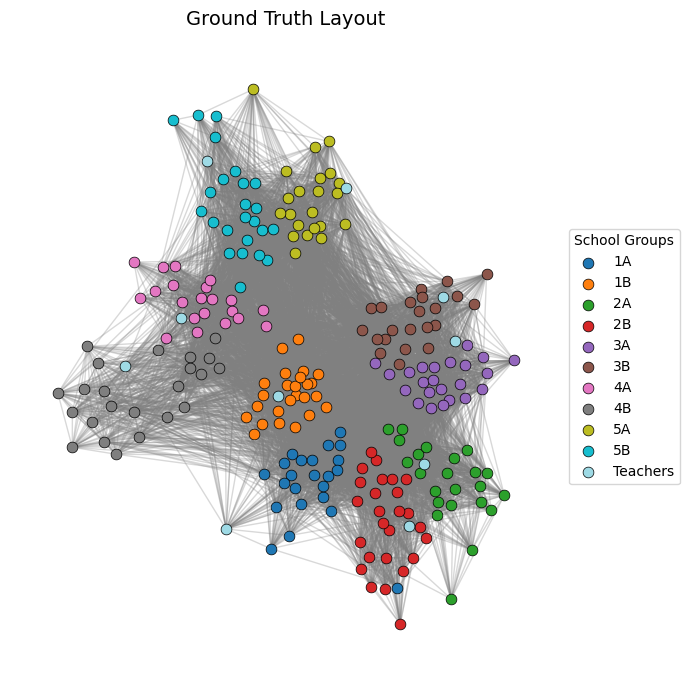

In [26]:
edge_widths, edge_alpha, _ = get_edge_styles(G_weighted, weighted=False)

ground_truth_dict = {str(k): v for k, v in ground_truth_dict.items()}
# 3. Отрисовка
plot_ground_truth(
    G=G_unweighted, 
    pos=master_pos, 
    ground_truth_dict=ground_truth_dict, 
    edge_widths=edge_widths, 
    edge_alpha=edge_alpha, 
    filename_base="primary_school"
)

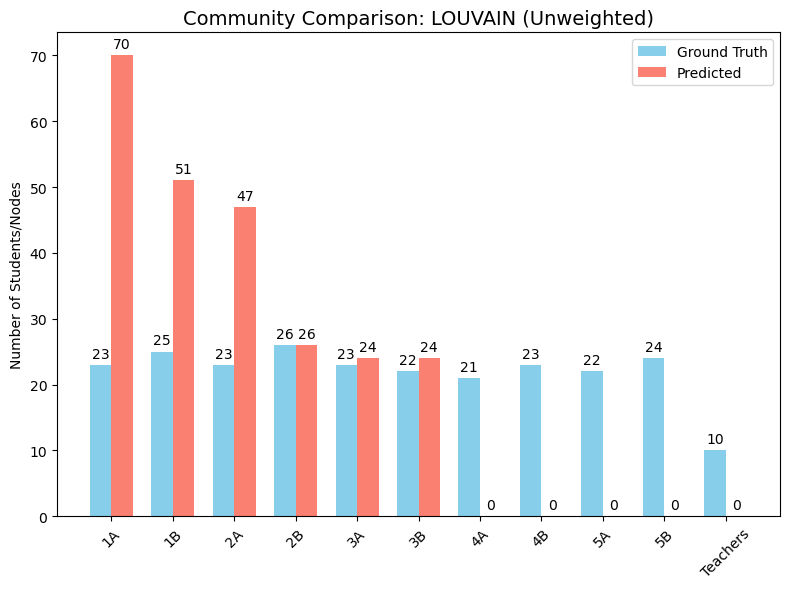

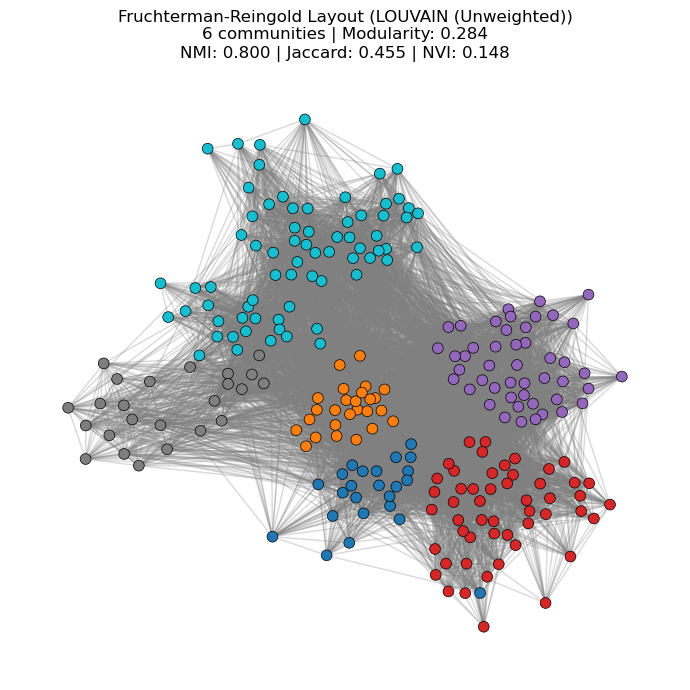

In [27]:
detect_communities('louvain', G_unweighted, weighted=False, 
                   pos_fr=master_pos)

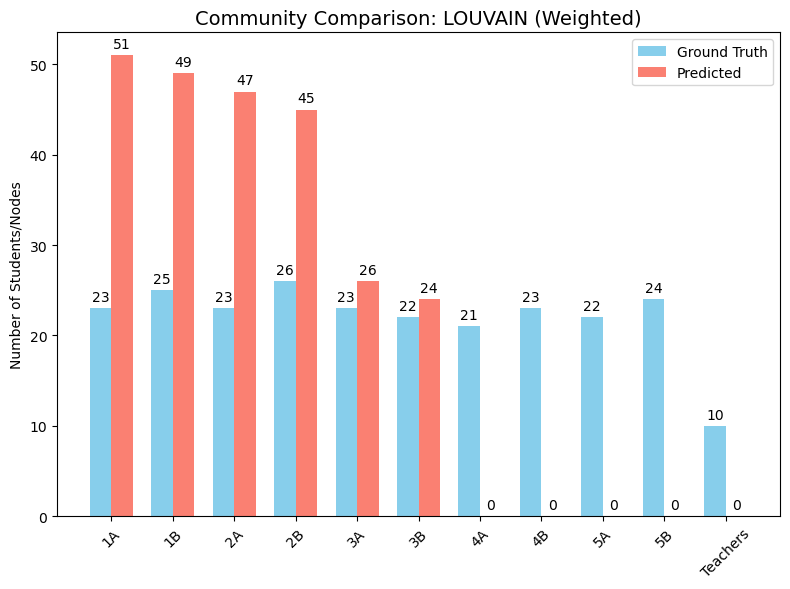

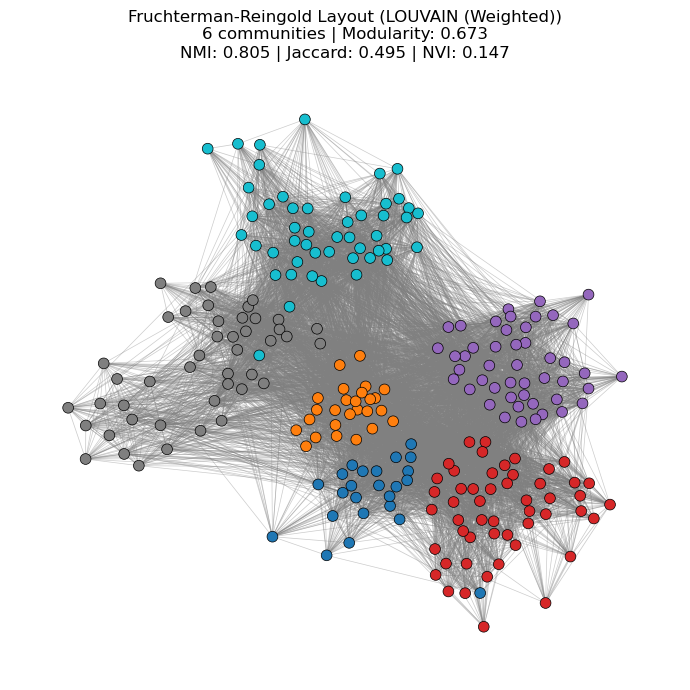

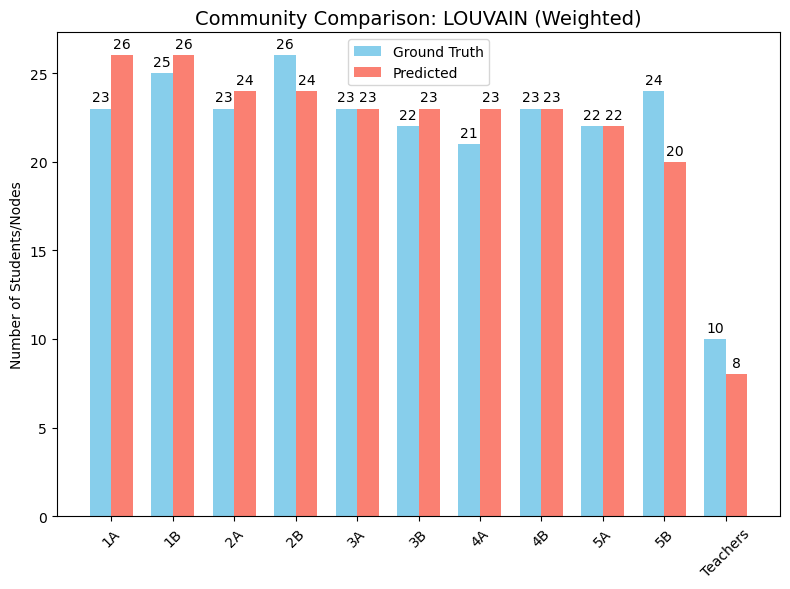

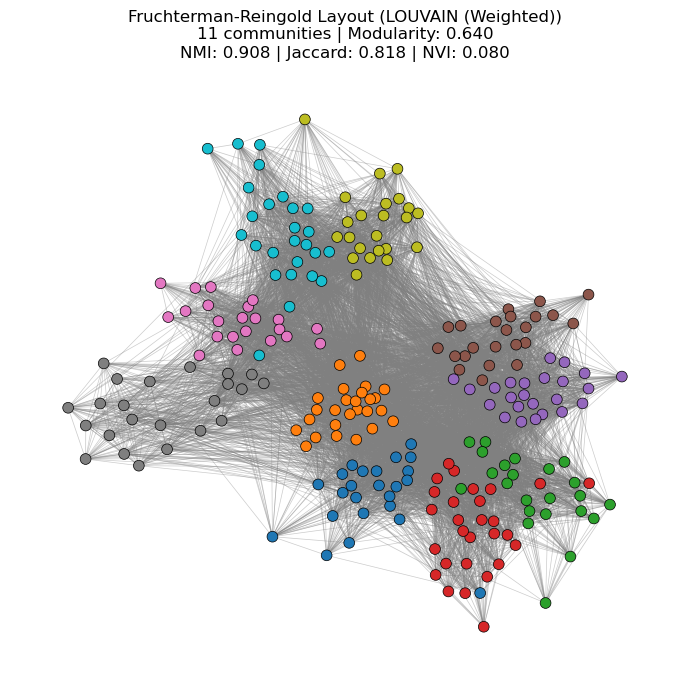

In [28]:
detect_communities('louvain', G_weighted, resolution=1.0, weighted=True, 
                   pos_fr=master_pos)

detect_communities('louvain', G_weighted, resolution=3.0, weighted=True, 
                   pos_fr=master_pos)

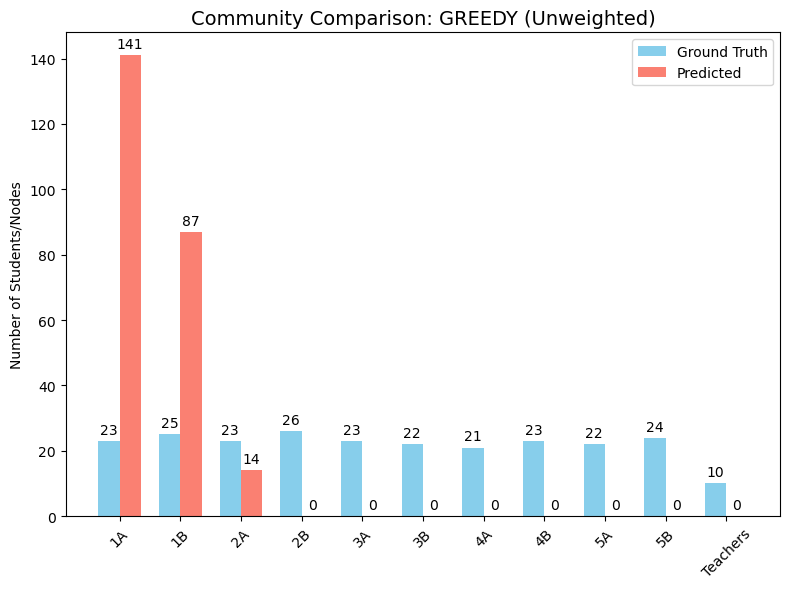

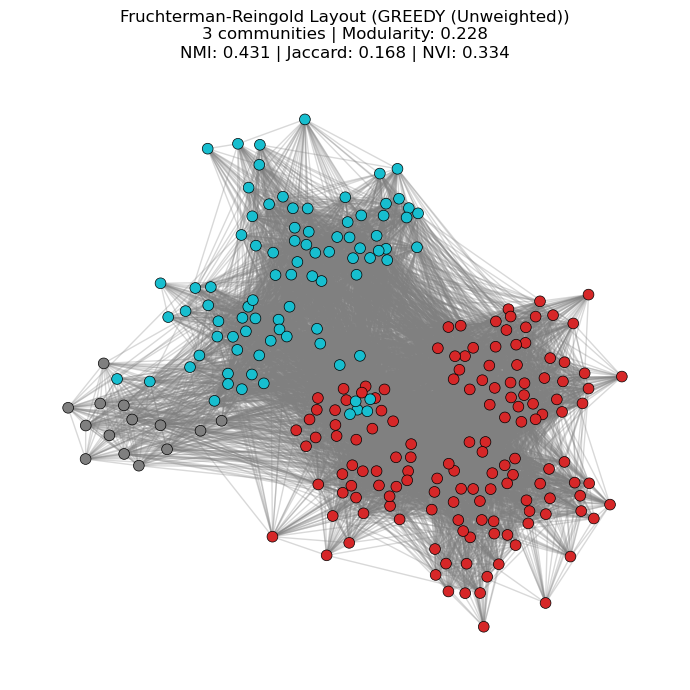

In [29]:
detect_communities('greedy', G_unweighted, weighted=False, 
                   pos_fr=master_pos)

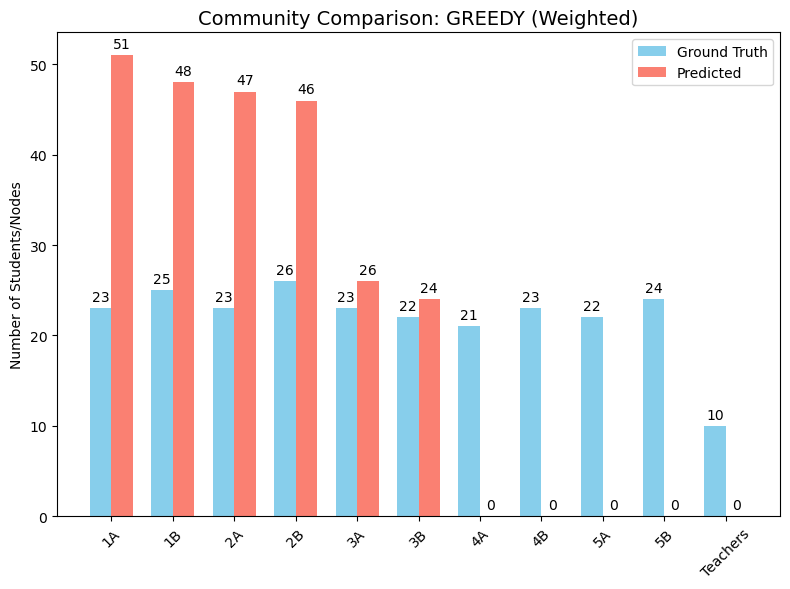

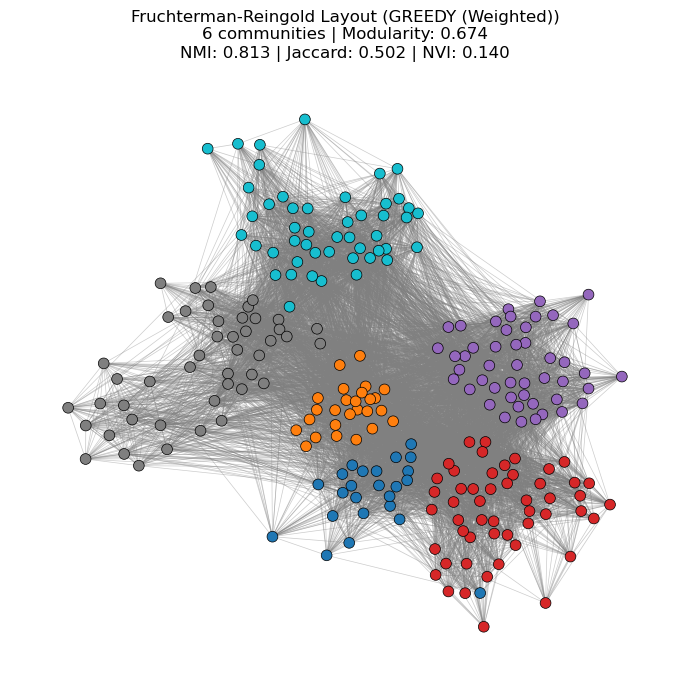

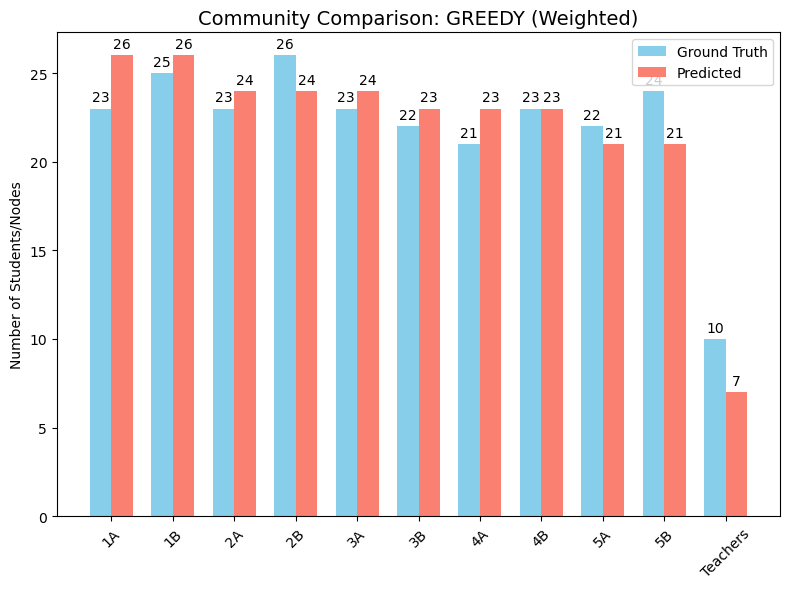

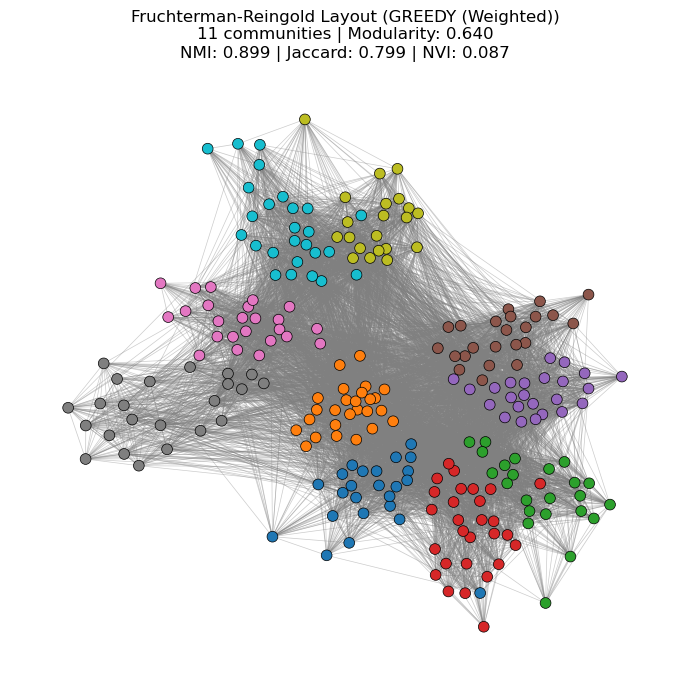

In [30]:
detect_communities('greedy', G_weighted, resolution=1.0, weighted=True, 
                   pos_fr=master_pos)

detect_communities('greedy', G_weighted, resolution=3.0, weighted=True, 
                   pos_fr=master_pos)

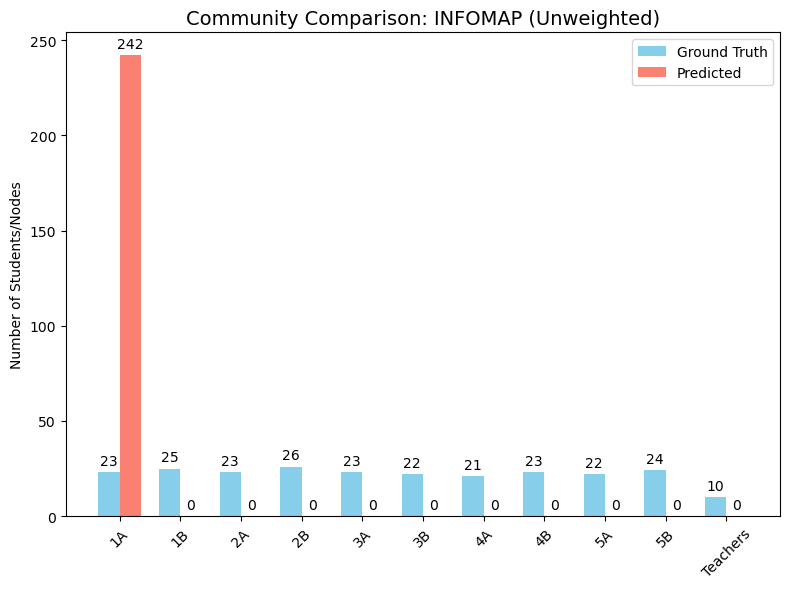

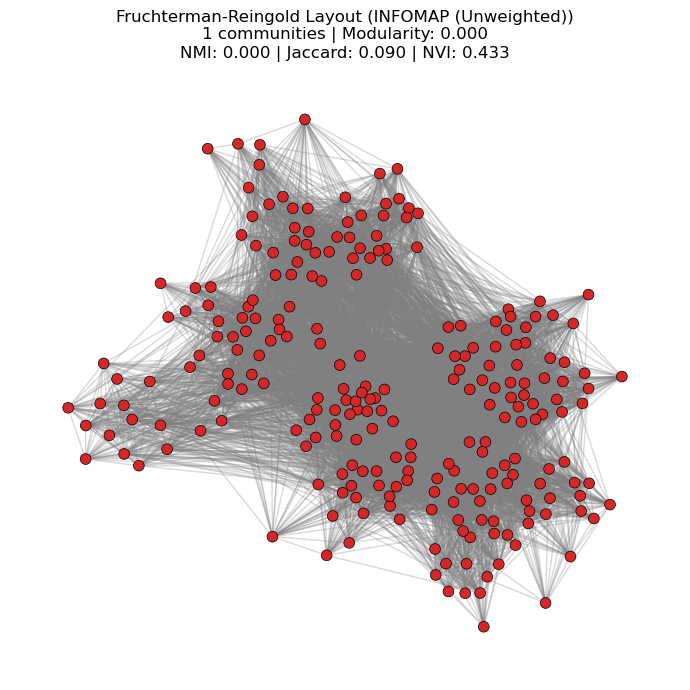

In [31]:
detect_communities('infomap', G_unweighted, weighted=False, 
                   pos_fr=master_pos)

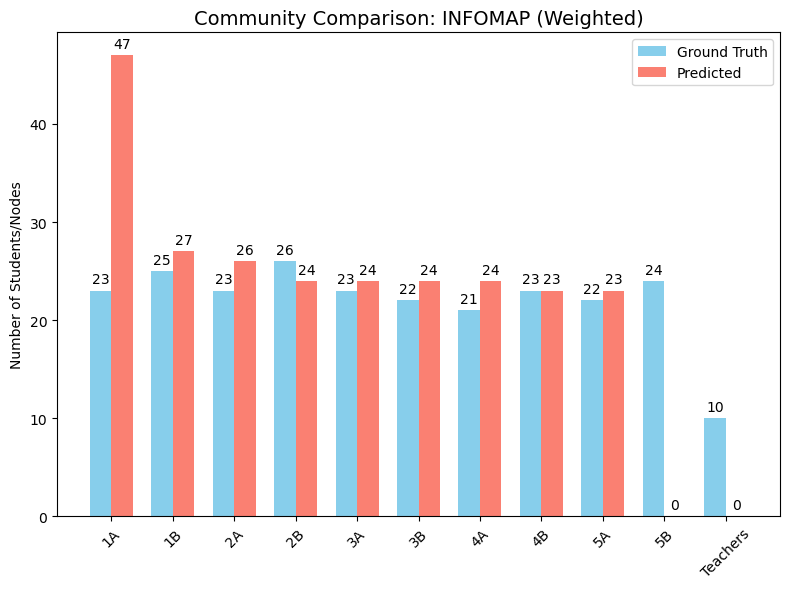

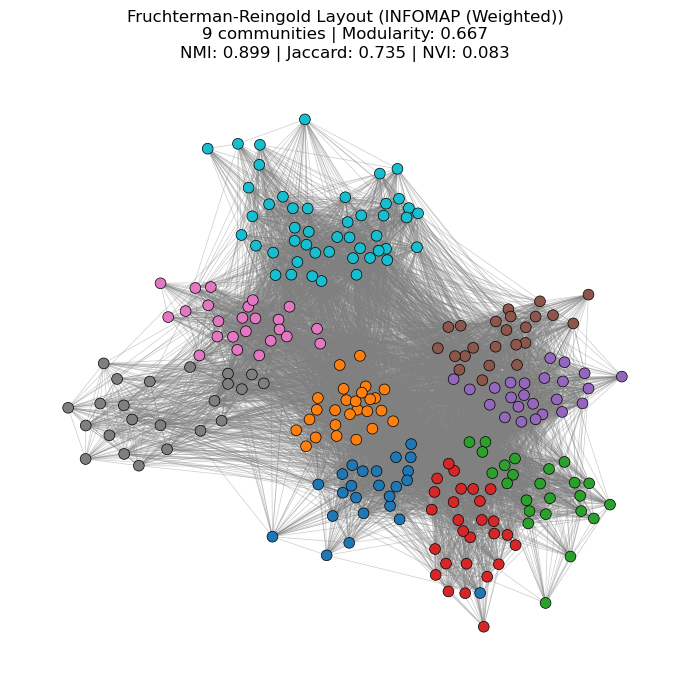

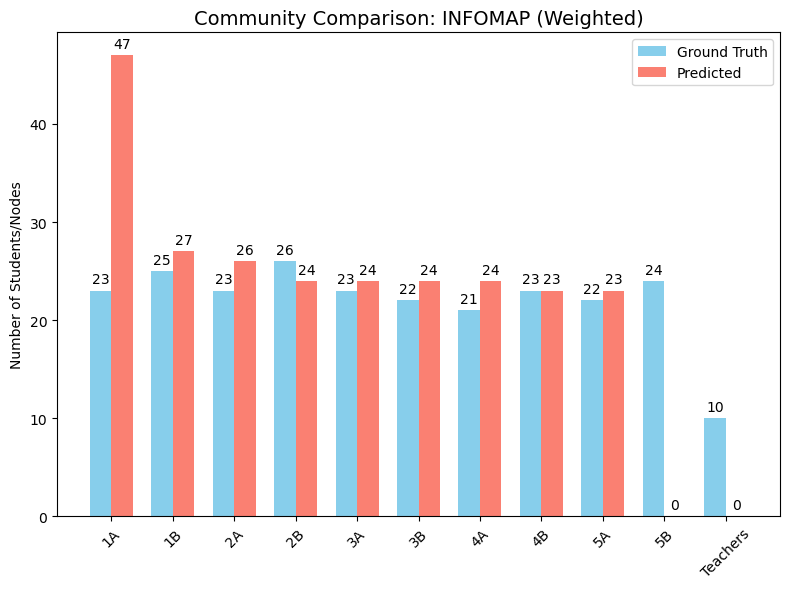

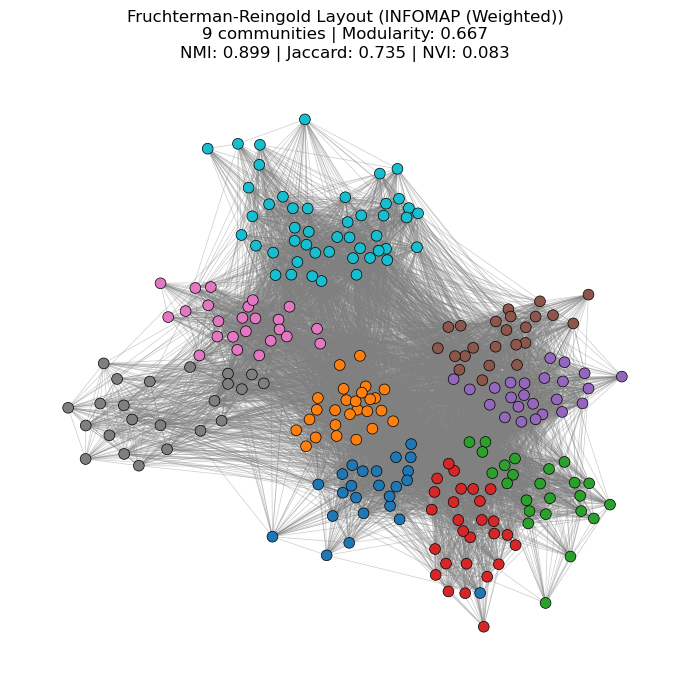

In [33]:
detect_communities('infomap', G_weighted, resolution=1.0, weighted=True, 
                   pos_fr=master_pos)

detect_communities('infomap', G_weighted, resolution=3.0, weighted=True, 
                   pos_fr=master_pos)